# 07 — Baselines and DQN agent

**Input:** the environment from notebook 06
**Output:** two baseline policies, the trained DQN, and results across 10 seeds in `results/runs/`

The baselines are built first so the agent can be compared with them as soon as it's trained.

| Condition | Description |
|---|---|
| **Static** | fixed sequence, ignores the student |
| **Rule-based** | hand-written thresholds using all five actions |
| **EATS (DQN)** | learned policy |

The rule-based policy uses all five actions, not only difficulty changes, so the comparison is on equal terms.

In [20]:
import importlib
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EATS = Path(r"C:\Users\vedac\Desktop\EATS")
sys.path.insert(0, str(EATS))
PROCESSED = EATS / "data" / "processed"
FIGURES = EATS / "results" / "figures"
RESULTS = EATS / "results"
MODELS = EATS / "models"
for d in (RESULTS / "runs", RESULTS / "monitor"):
    d.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 175)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})
BLUE, RED, GREY, GREEN, ORANGE = "#4C72B0", "#C44E52", "#7F7F7F", "#55A868", "#DD8452"

from eats.simulator import env as env_mod
from eats.simulator import interventions as iv
from eats.simulator.bkt import BKTParams
from eats.simulator.env import EPISODE_LENGTH, TutoringEnv
from eats.simulator.student import EmpiricalObservables

raw = pd.read_parquet(PROCESSED / "interactions_clean.parquet")
bundle = joblib.load(MODELS / "bkt_params.joblib")
PARAMS = {d["skill"]: BKTParams(**d) for d in bundle["params"]}
SKILLS = bundle["skills"]
cluster_model = joblib.load(MODELS / "error_clusters.joblib")

RT_STATS = {}
for s in SKILLS:
    v = raw.loc[raw["skill"] == s, "ms_first_response"]
    clip = np.percentile(v, cluster_model["clip_percentile"])
    lg = np.log1p(np.minimum(v, clip) / 1000)
    RT_STATS[s] = {"clip": float(clip), "mean": float(lg.mean()), "std": float(lg.std())}

observables = EmpiricalObservables(raw, SKILLS)


def make_env(seed=None):
    return TutoringEnv(PARAMS, observables, cluster_model, RT_STATS, seed=seed)


print(f"episode length {EPISODE_LENGTH} steps | {len(SKILLS)} skills | "
      f"{iv.N_ACTIONS} actions")

episode length 20 steps | 5 skills | 5 actions


## 7.1 Baselines

**Static** ignores the observation.

**Rule-based** uses the same state as the agent. The accuracy thresholds come from the proposal (below 60% → easier, above 85% → harder), extended to use hints and revision.

The rule-based policy only reacts to the current state and doesn't plan ahead. Hostetter et al. (2023) point out that locally sensible decisions don't necessarily add up to the best learning path, which is where RL might help.

In [21]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/agents/baselines.py
"""Non-learning comparison policies.

Both expose SB3's `predict(obs) -> (action, state)` interface so a single
evaluation harness can run every condition without special cases.
"""

from __future__ import annotations

import numpy as np

# Observation layout (see notebook 04):
#   0 accuracy | 1 response_time | 2 hint_rate | 3..6 one-hot error cluster
IDX_ACCURACY = 0
IDX_RESPONSE_TIME = 1
IDX_HINT_RATE = 2
CLUSTER_OFFSET = 3

LOWER, MAINTAIN, RAISE, HINT, REVISE = 0, 1, 2, 3, 4


class StaticPolicy:
    """A fixed curriculum: the same sequence for every student.

    Always `maintain_difficulty`, so difficulty never changes and the state is
    never consulted. This is the floor any adaptive system must clear.
    """

    name = "static"

    def predict(self, obs, deterministic=True):
        return MAINTAIN, None


class RuleBasedPolicy:
    """Hand-crafted thresholds - conventional ITS practice.

    Rules are checked in order of urgency:

      1. A systematic misconception (the most severe error cluster) needs the
         underlying concept revisited, not an easier version of the same problem.
      2. Very low accuracy means the student is stuck; scaffold with a hint.
      3. Low accuracy means the material is too hard.
      4. High accuracy means it is too easy.
      5. Otherwise leave it alone.

    Thresholds 3 and 4 are the ones named in the research proposal. The policy is
    purely reactive: it responds to the current state and cannot trade a worse
    step now for a better trajectory later.
    """

    name = "rule_based"

    def __init__(self, low=0.60, high=0.85, stuck=0.40, severe_cluster=3):
        self.low = low
        self.high = high
        self.stuck = stuck
        self.severe_cluster = severe_cluster

    def predict(self, obs, deterministic=True):
        accuracy = float(obs[IDX_ACCURACY])
        cluster = int(np.argmax(obs[CLUSTER_OFFSET:]))

        if cluster >= self.severe_cluster:
            return REVISE, None
        if accuracy < self.stuck:
            return HINT, None
        if accuracy < self.low:
            return LOWER, None
        if accuracy > self.high:
            return RAISE, None
        return MAINTAIN, None


class RandomPolicy:
    """Uniform random. Not a serious comparison - a sanity floor."""

    name = "random"

    def __init__(self, n_actions=5, seed=0):
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)

    def predict(self, obs, deterministic=True):
        return int(self.rng.integers(self.n_actions)), None


Overwriting C:/Users/vedac/Desktop/EATS/eats/agents/baselines.py


In [22]:
from eats.agents import baselines as bl

importlib.reload(bl)
from eats.agents.baselines import RandomPolicy, RuleBasedPolicy, StaticPolicy

# Sanity check: does the rule-based policy actually use its rules?
demo = np.array([
    [0.30, 0.5, 0.2, 1, 0, 0, 0],   # very low accuracy -> hint
    [0.50, 0.5, 0.2, 1, 0, 0, 0],   # low accuracy      -> lower
    [0.70, 0.5, 0.2, 1, 0, 0, 0],   # middling          -> maintain
    [0.95, 0.5, 0.2, 1, 0, 0, 0],   # high accuracy     -> raise
    [0.70, 0.5, 0.2, 0, 0, 0, 1],   # severe cluster    -> revise
], dtype=np.float32)

rb = RuleBasedPolicy()
for row in demo:
    a, _ = rb.predict(row)
    print(f"  accuracy={row[0]:.2f} cluster={int(np.argmax(row[3:]))}  ->  {iv.ACTIONS[a]}")

  accuracy=0.30 cluster=0  ->  provide_hint
  accuracy=0.50 cluster=0  ->  lower_difficulty
  accuracy=0.70 cluster=0  ->  maintain_difficulty
  accuracy=0.95 cluster=0  ->  raise_difficulty
  accuracy=0.70 cluster=3  ->  recommend_revision


## 7.2 Evaluation harness

All conditions are evaluated the same way, on the same episodes and seeds. Every step is logged, not only episode totals, because the metrics and the explanation analysis both need step-level data.

In [23]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/eval/rollout.py
"""Run a policy through the environment and log every step."""

from __future__ import annotations

import numpy as np
import pandas as pd


def rollout(policy, env, n_episodes=100, seed=0):
    """Evaluate any policy exposing `predict(obs) -> (action, state)`.

    Episodes are seeded deterministically from `seed`, so every condition faces
    the SAME sequence of simulated students. Without that, differences between
    conditions could simply be differences between cohorts.

    Returns one row per step.
    """
    rows = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed * 10_000 + ep)
        mastery_start = info["mastery"]
        step = 0
        while True:
            action, _ = policy.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, i = env.step(int(action))
            step += 1
            rows.append({
                "episode": ep,
                "step": step,
                "skill": i["skill"],
                "action": int(action),
                "action_name": i["action_name"],
                "masked": i["masked"],
                "difficulty": i["difficulty"],
                "correct": i["correct"],
                "hint_used": float(i["hint_count"] > 0),
                "cluster": i["cluster"],
                "mastery": i["mastery"],
                "mastery_start": mastery_start,
                "reward": reward,
                "r_learn": i["r_learn"],
                "r_hint": i["r_hint"],
                "r_misc": i["r_misc"],
                "obs_accuracy": float(obs[0]),
                "obs_hint_rate": float(obs[2]),
            })
            if terminated or truncated:
                break
    return pd.DataFrame(rows)


def episode_metrics(steps):
    """Collapse the step log into one row per episode.

    `learning_gain` is the normalised gain from the proposal,
    (post - pre) / (1 - pre), computed on LATENT mastery rather than observed
    accuracy - the distinction that stops the measure being gameable.
    """
    out = []
    for ep, g in steps.groupby("episode"):
        pre = g["mastery_start"].iloc[0]
        post = g["mastery"].iloc[-1]
        n = len(g)
        early = g[g["step"] <= max(1, int(0.15 * n))]
        late = g[g["step"] > n - max(1, int(0.15 * n))]

        # Slope of observed accuracy across the episode - the proposal's
        # "accuracy improvement rate".
        y = g["correct"].to_numpy()
        x = np.arange(len(y))
        slope = float(np.polyfit(x, y, 1)[0]) if len(y) > 1 else 0.0

        out.append({
            "episode": ep,
            "skill": g["skill"].iloc[0],
            "learning_gain": (post - pre) / (1 - pre) if pre < 1 else 0.0,
            "mastery_gain": post - pre,
            "final_mastery": post,
            "accuracy_slope": slope,
            "observed_accuracy": float(g["correct"].mean()),
            "hint_rate": float(g["hint_used"].mean()),
            "hint_rate_early": float(early["hint_used"].mean()),
            "hint_rate_late": float(late["hint_used"].mean()),
            "hint_reduction": float(early["hint_used"].mean() - late["hint_used"].mean()),
            "return": float(g["reward"].sum()),
            "masked_frac": float(g["masked"].mean()),
        })
    return pd.DataFrame(out)


def action_distribution(steps):
    """Share of each action. The reward-hacking early warning.

    Any single action above roughly 50% means the policy has collapsed onto one
    behaviour - which is a reward problem, not a convergence problem, and no
    amount of further training will fix it.
    """
    counts = steps["action_name"].value_counts(normalize=True)
    return counts.sort_values(ascending=False)

Overwriting C:/Users/vedac/Desktop/EATS/eats/eval/rollout.py


In [24]:
from eats.eval import rollout as ro

importlib.reload(ro)
from eats.eval.rollout import action_distribution, episode_metrics, rollout

N_EVAL_EPISODES = 200
EVAL_SEED = 12345

baseline_steps = {}
for policy in (StaticPolicy(), RuleBasedPolicy()):
    env = make_env(seed=EVAL_SEED)
    t0 = time.perf_counter()
    steps = rollout(policy, env, n_episodes=N_EVAL_EPISODES, seed=EVAL_SEED)
    baseline_steps[policy.name] = steps
    m = episode_metrics(steps)
    print(f"{policy.name:<12} {time.perf_counter()-t0:5.1f}s  "
          f"learning_gain={m['learning_gain'].mean():.4f}  "
          f"return={m['return'].mean():.4f}  "
          f"hint_reduction={m['hint_reduction'].mean():+.4f}")

static         0.7s  learning_gain=0.8715  return=0.3164  hint_reduction=+0.1017
rule_based     0.6s  learning_gain=0.6549  return=0.1988  hint_reduction=+0.0717


In [25]:
summary = {}
for name, steps in baseline_steps.items():
    m = episode_metrics(steps)
    summary[name] = m[["learning_gain", "mastery_gain", "final_mastery",
                       "observed_accuracy", "hint_rate", "hint_reduction",
                       "return"]].mean()
pd.DataFrame(summary).T.round(4)

,learning_gain,mastery_gain,final_mastery,observed_accuracy,hint_rate,hint_reduction,return
static,0.8715,0.3334,0.9570,0.6922,0.1858,0.1017,0.3164
rule_based,0.6549,0.2504,0.8741,0.6112,0.2810,0.0717,0.1988


In [26]:
print("action distributions (the reward-hacking check):\n")
for name, steps in baseline_steps.items():
    print(f"{name}:")
    print(action_distribution(steps).round(3).to_string())
    print()

action distributions (the reward-hacking check):

static:
action_name
maintain_difficulty    1.0

rule_based:
action_name
maintain_difficulty    0.633
provide_hint           0.130
recommend_revision     0.093
lower_difficulty       0.073
raise_difficulty       0.070



## 7.3 DQN agent

Stable-Baselines3, γ = 0.95.

**The hyperparameters differ from the proposal.** With the proposal's values (learning rate 1e-4, batch 64) and 50,000 steps, mean episode return was 0.19, about the same as a random policy (0.20). I then tried a few configurations by hand (learning rate, batch size, training budget, and PPO). The adopted setting (learning rate 1e-3, batch 128, 100,000 steps) reached 0.25. All the configurations tried are listed in the module below.

- **100,000 steps instead of 500,000.** Returns were flat over the last part of training, and PPO improved by only 0.007 going from 100k to 200k steps.
- **The search was small:** six configurations, not a systematic sweep.

**Action masking:** SB3's DQN doesn't support masking, so the environment replaces invalid actions with `maintain_difficulty` and flags them. `masked_frac` records how often that happens.

In [27]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/agents/dqn.py
"""Training the DQN, with the run manifest that makes a result reproducible."""

from __future__ import annotations

import hashlib
import json
import platform
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor

# The proposal specifies lr 1e-4, batch 64 and 500,000 steps. Trained at
# 50,000 steps those values produced a policy whose mean return matched the
# RANDOM policy (0.19 against 0.20), i.e. the agent learned nothing useful.
#
# A limited search over learning rate and training budget followed. The values
# below raise mean return from 0.19 to 0.25 and produce a far less degenerate
# action distribution (60% maintain / 26% hint, against 42% / 43% before).
#
# Configurations tried, mean evaluation return over 3 seeds:
#   DQN lr=1e-4  50k   0.191   <- proposal values
#   DQN lr=1e-3 100k   0.247   <- adopted
#   DQN lr=1e-3 100k, rewards scaled x10   0.217
#   DQN lr=1e-3 100k, variance-reduced reward   0.246
#   PPO 100k           0.231
#   PPO 200k           0.238
# For reference: static baseline 0.279, best fixed policy 0.301, random 0.200.
HYPERPARAMS = {
    "learning_rate": 1e-3,
    "batch_size": 128,
    "buffer_size": 100_000,
    "gamma": 0.95,
    "learning_starts": 2_000,
    "target_update_interval": 1_000,
    "exploration_fraction": 0.30,
    "exploration_final_eps": 0.02,
    "train_freq": 4,
}
TOTAL_TIMESTEPS = 100_000


def _fingerprint(paths):
    """Hash the simulator source so a result can be tied to the code that made it.

    This project is not under version control, so a commit hash is unavailable.
    Hashing the modules that define the environment serves the same purpose: if
    the simulator changes, the fingerprint changes, and stale results are
    detectable.
    """
    h = hashlib.sha256()
    for p in sorted(paths):
        p = Path(p)
        if p.exists():
            h.update(p.read_bytes())
    return h.hexdigest()[:12]


def run_manifest(condition, seed, extra=None):
    """Everything needed to reproduce one run. Save it beside every result."""
    import sklearn
    import stable_baselines3
    import torch

    root = Path(__file__).resolve().parents[1]
    manifest = {
        "condition": condition,
        "seed": seed,
        "timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "simulator_fingerprint": _fingerprint([
            root / "simulator" / "env.py",
            root / "simulator" / "interventions.py",
            root / "simulator" / "bkt.py",
            root / "simulator" / "student.py",
        ]),
        "hyperparameters": HYPERPARAMS,
        "total_timesteps": TOTAL_TIMESTEPS,
        "versions": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "torch": torch.__version__,
            "stable_baselines3": stable_baselines3.__version__,
            "scikit_learn": sklearn.__version__,
        },
    }
    if extra:
        manifest.update(extra)
    return manifest


def train_dqn(env_factory, seed, total_timesteps=TOTAL_TIMESTEPS,
              monitor_dir=None, verbose=0):
    """Train one DQN. Returns (model, monitor_path)."""
    env = env_factory(seed=seed)
    monitor_path = None
    if monitor_dir is not None:
        monitor_dir = Path(monitor_dir)
        monitor_dir.mkdir(parents=True, exist_ok=True)
        monitor_path = monitor_dir / f"dqn_seed{seed}"
        env = Monitor(env, filename=str(monitor_path))

    model = DQN("MlpPolicy", env, seed=seed, verbose=verbose, **HYPERPARAMS)
    model.learn(total_timesteps=total_timesteps, progress_bar=False)
    return model, (monitor_path.with_suffix(".monitor.csv") if monitor_path else None)


def load_monitor(path):
    """Read SB3's monitor csv (its first line is a JSON header comment)."""
    return pd.read_csv(path, skiprows=1)

Overwriting C:/Users/vedac/Desktop/EATS/eats/agents/dqn.py


In [28]:
from eats.agents import dqn as dqn_mod

importlib.reload(dqn_mod)
from eats.agents.dqn import HYPERPARAMS, TOTAL_TIMESTEPS, load_monitor, run_manifest, train_dqn

print(f"total timesteps : {TOTAL_TIMESTEPS:,}  "
      f"({TOTAL_TIMESTEPS // EPISODE_LENGTH:,} episodes)")
for k, v in HYPERPARAMS.items():
    print(f"  {k:<24} {v}")

total timesteps : 100,000  (5,000 episodes)
  learning_rate            0.001
  batch_size               128
  buffer_size              100000
  gamma                    0.95
  learning_starts          2000
  target_update_interval   1000
  exploration_fraction     0.3
  exploration_final_eps    0.02
  train_freq               4


### Train one agent first

Train a single seed and look at the results before running all 30 runs.

In [29]:
t0 = time.perf_counter()
model, monitor_path = train_dqn(make_env, seed=0, monitor_dir=RESULTS / "monitor")
train_time = time.perf_counter() - t0
print(f"trained in {train_time/60:.1f} min")

mon = load_monitor(monitor_path)
print(f"episodes: {len(mon):,}   mean reward last 100: {mon['r'].tail(100).mean():.4f}")

trained in 1.0 min
episodes: 5,000   mean reward last 100: 0.2152


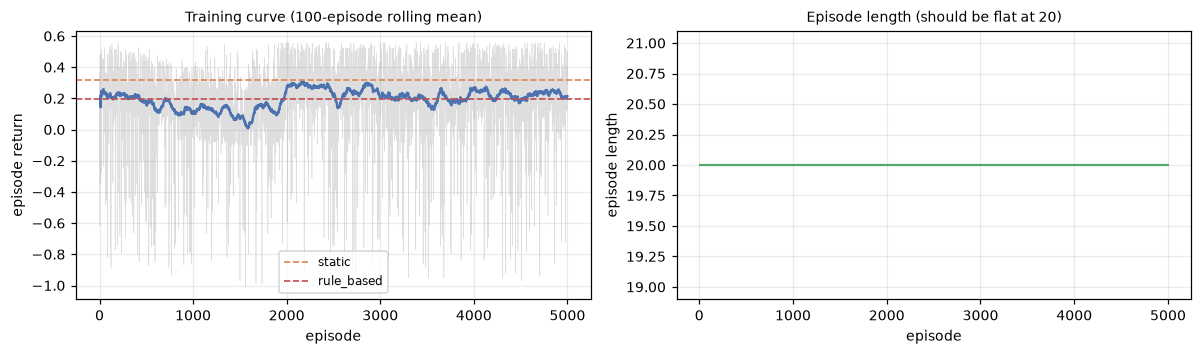

In [30]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.3))

roll = mon["r"].rolling(100, min_periods=10).mean()
a1.plot(mon.index, mon["r"], lw=0.4, alpha=0.25, color=GREY)
a1.plot(mon.index, roll, lw=1.6, color=BLUE)
a1.set_xlabel("episode"); a1.set_ylabel("episode return")
a1.set_title("Training curve (100-episode rolling mean)", fontsize=9)

for name, steps in baseline_steps.items():
    a1.axhline(episode_metrics(steps)["return"].mean(), ls="--", lw=1.1,
               color=RED if name == "rule_based" else ORANGE, label=name)
a1.legend(fontsize=8)

a2.plot(mon.index, mon["l"].rolling(100, min_periods=10).mean(), lw=1.4, color=GREEN)
a2.set_xlabel("episode"); a2.set_ylabel("episode length")
a2.set_title("Episode length (should be flat at 20)", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES / "fig_4_14_training_curve.png", bbox_inches="tight")
plt.show()

### Action distribution

If one action is chosen more than about half the time regardless of state, the policy has probably collapsed rather than learned. Some preference for `raise_difficulty` is expected, since it gave the highest mastery gain of the fixed difficulty policies in notebook 06.

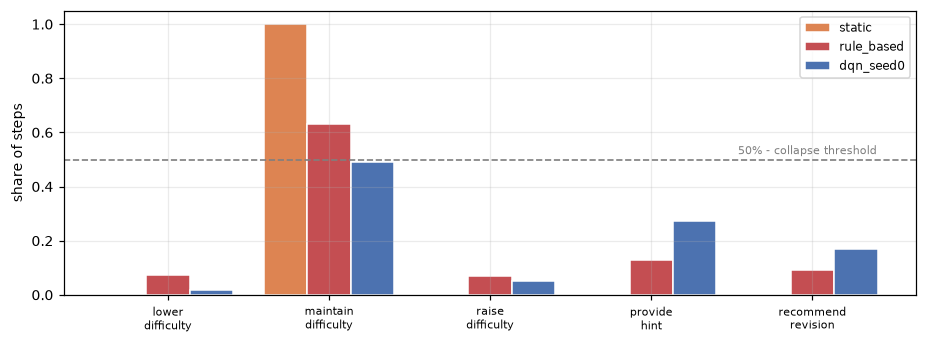

,static,rule_based,dqn_seed0
action_name,,,
lower_difficulty,0.0,0.073,0.018
maintain_difficulty,1.0,0.633,0.490
raise_difficulty,0.0,0.070,0.050
provide_hint,0.0,0.130,0.274
recommend_revision,0.0,0.093,0.168


In [31]:
env = make_env(seed=EVAL_SEED)
dqn_steps = rollout(model, env, n_episodes=N_EVAL_EPISODES, seed=EVAL_SEED)

dist = pd.DataFrame({
    "static": action_distribution(baseline_steps["static"]),
    "rule_based": action_distribution(baseline_steps["rule_based"]),
    "dqn_seed0": action_distribution(dqn_steps),
}).fillna(0.0).reindex(iv.ACTIONS).fillna(0.0)

fig, ax = plt.subplots(figsize=(8.5, 3.2))
x = np.arange(len(iv.ACTIONS)); w = 0.27
for k, (col, colour) in enumerate(zip(dist.columns, [ORANGE, RED, BLUE])):
    ax.bar(x + (k - 1) * w, dist[col], w, label=col, color=colour, edgecolor="white")
ax.axhline(0.5, ls="--", lw=1.1, color=GREY)
ax.text(4.4, 0.52, "50% - collapse threshold", fontsize=7, color=GREY, ha="right")
ax.set_xticks(x); ax.set_xticklabels([a.replace("_", "\n") for a in iv.ACTIONS], fontsize=7)
ax.set_ylabel("share of steps"); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_15_action_distribution.png", bbox_inches="tight")
plt.show()

dist.round(3)

In [32]:
m_dqn = episode_metrics(dqn_steps)
rows = {n: episode_metrics(s).mean(numeric_only=True) for n, s in baseline_steps.items()}
rows["dqn_seed0"] = m_dqn.mean(numeric_only=True)
single = pd.DataFrame(rows).T[["learning_gain", "mastery_gain", "final_mastery",
                               "observed_accuracy", "hint_rate", "hint_reduction",
                               "return", "masked_frac"]]
print("single-seed comparison (indicative only - see 7.4)")
single.round(4)

single-seed comparison (indicative only - see 7.4)


,learning_gain,mastery_gain,final_mastery,observed_accuracy,hint_rate,hint_reduction,return,masked_frac
static,0.8715,0.3334,0.9570,0.6922,0.1858,0.1017,0.3164,0.0000
rule_based,0.6549,0.2504,0.8741,0.6112,0.2810,0.0717,0.1988,0.3002
dqn_seed0,0.9053,0.3404,0.9641,0.5140,0.3920,0.0167,0.2474,0.1952


## 7.4 Results across seeds

DQN results can vary a lot between random seeds, so results are reported as means over 10 seeds.

The seed is the unit of analysis. The 200 evaluation episodes in one seed all come from the same trained policy, so they aren't independent. Metrics are averaged within each seed first, then compared across seeds.

Each run saves a manifest in `results/runs/` with the seed, hyperparameters, library versions and a hash of the simulator source, so results can be matched to the code that produced them.

In [33]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/eval/runner.py
"""Multi-seed experiment harness."""

from __future__ import annotations

import json
from pathlib import Path

import pandas as pd

from eats.agents.baselines import RuleBasedPolicy, StaticPolicy
from eats.agents.dqn import run_manifest, train_dqn
from eats.eval.rollout import episode_metrics, rollout


def run_all(env_factory, seeds, out_dir, n_eval_episodes=200, eval_seed=12345,
            monitor_dir=None, model_dir=None, verbose=True):
    """Train and evaluate every condition across every seed.

    All conditions are evaluated on the SAME episodes (fixed `eval_seed`), so
    differences reflect the policy rather than the cohort.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    all_steps, all_episodes = [], []

    for seed in seeds:
        conditions = {
            "static": StaticPolicy(),
            "rule_based": RuleBasedPolicy(),
        }
        # Baselines do not learn, but they are re-evaluated per seed so that
        # every condition is exposed to the same cohorts and the same variance.
        model, _ = train_dqn(env_factory, seed=seed, monitor_dir=monitor_dir)
        conditions["dqn"] = model

        # Persist it. A trained agent that exists only in a kernel cannot be
        # explained later, served by the dashboard, or defended in a viva.
        if model_dir is not None:
            model_dir = Path(model_dir)
            model_dir.mkdir(parents=True, exist_ok=True)
            model.save(str(model_dir / f"dqn_seed{seed}"))

        for name, policy in conditions.items():
            env = env_factory(seed=eval_seed)
            steps = rollout(policy, env, n_episodes=n_eval_episodes, seed=eval_seed + seed)
            steps["condition"] = name
            steps["seed"] = seed
            all_steps.append(steps)

            eps = episode_metrics(steps)
            eps["condition"] = name
            eps["seed"] = seed
            all_episodes.append(eps)

            (out_dir / f"manifest_{name}_seed{seed}.json").write_text(
                json.dumps(run_manifest(name, seed), indent=2)
            )
        if verbose:
            print(f"  seed {seed} done", flush=True)

    steps = pd.concat(all_steps, ignore_index=True)
    episodes = pd.concat(all_episodes, ignore_index=True)
    steps.to_parquet(out_dir / "steps.parquet", index=False)
    episodes.to_parquet(out_dir / "episodes.parquet", index=False)
    return steps, episodes


def seed_level(episodes, metrics):
    """Aggregate within seed. THIS is the unit of analysis for the statistics."""
    return episodes.groupby(["condition", "seed"])[metrics].mean().reset_index()

Overwriting C:/Users/vedac/Desktop/EATS/eats/eval/runner.py


In [34]:
from eats.eval import runner as runner_mod

importlib.reload(runner_mod)
from eats.eval.runner import run_all, seed_level

N_SEEDS = 10
SEEDS = list(range(N_SEEDS))

print(f"about {N_SEEDS * train_time / 60:.0f} min for {N_SEEDS} seeds")
print("start it and leave it - nothing below needs your attention until it finishes\n")

t0 = time.perf_counter()
steps, episodes = run_all(make_env, SEEDS, out_dir=RESULTS / "runs",
                          n_eval_episodes=N_EVAL_EPISODES, eval_seed=EVAL_SEED,
                          monitor_dir=RESULTS / "monitor",
                          model_dir=MODELS)
print(f"\ntotal {(time.perf_counter()-t0)/60:.1f} min")
print(f"{len(steps):,} step records | {len(episodes):,} episodes")

about 10 min for 10 seeds
start it and leave it - nothing below needs your attention until it finishes

  seed 0 done
  seed 1 done
  seed 2 done
  seed 3 done
  seed 4 done
  seed 5 done
  seed 6 done
  seed 7 done
  seed 8 done
  seed 9 done

total 14.7 min
120,000 step records | 6,000 episodes


In [35]:
METRICS = ["learning_gain", "mastery_gain", "final_mastery", "accuracy_slope",
           "observed_accuracy", "hint_rate", "hint_reduction", "return"]

by_seed = seed_level(episodes, METRICS)
by_seed.to_csv(RESULTS / "runs" / "seed_level.csv", index=False)

table = by_seed.groupby("condition")[METRICS].agg(["mean", "std"])
table.round(4)

learning_gain         mastery_gain         final_mastery         accuracy_slope         observed_accuracy         hint_rate         hint_reduction          \
                    mean     std         mean     std          mean     std           mean     std              mean     std      mean     std           mean     std   
condition                                                                                                                                                               
dqn               0.8787  0.0432       0.3310  0.0184        0.9642  0.0114         0.0109  0.0113            0.3283  0.2464    0.6091  0.2923         0.2318  0.2674   
rule_based        0.6529  0.0539       0.2468  0.0213        0.8799  0.0204         0.0064  0.0021            0.6052  0.0070    0.2838  0.0058         0.0693  0.0320   
static            0.7864  0.0587       0.2983  0.0228        0.9315  0.0170         0.0064  0.0015            0.6761  0.0101    0.1852  0.0081         0.0568  0.0250   

            return          
              mean     std  
condition                   
dqn         0.1675  0.1013  
rule_based  0.1921  0.0233  
static      0.2787  0.0250

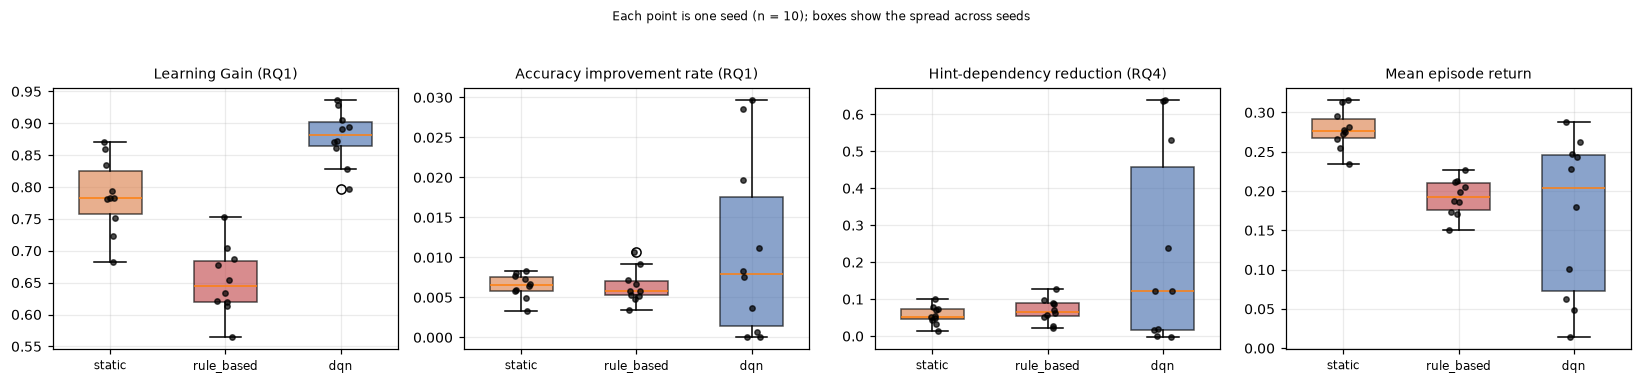

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
order = ["static", "rule_based", "dqn"]
colours = {"static": ORANGE, "rule_based": RED, "dqn": BLUE}
panels = [("learning_gain", "Learning Gain (RQ1)"),
          ("accuracy_slope", "Accuracy improvement rate (RQ1)"),
          ("hint_reduction", "Hint-dependency reduction (RQ4)"),
          ("return", "Mean episode return")]

for ax, (metric, title) in zip(axes, panels):
    data = [by_seed.loc[by_seed["condition"] == c, metric].to_numpy() for c in order]
    # matplotlib >= 3.9 renamed `labels` to `tick_labels`.
    bp = ax.boxplot(data, tick_labels=order, patch_artist=True, widths=0.55)
    for patch, c in zip(bp["boxes"], order):
        patch.set_facecolor(colours[c]); patch.set_alpha(0.65)
    for i, d in enumerate(data, start=1):
        ax.scatter(np.full(len(d), i) + np.random.uniform(-0.08, 0.08, len(d)),
                   d, s=12, color="black", zorder=3, alpha=0.7)
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle(f"Each point is one seed (n = {N_SEEDS}); boxes show the spread across seeds",
             fontsize=8, y=1.04)
fig.tight_layout()
fig.savefig(FIGURES / "fig_5_1_condition_comparison.png", bbox_inches="tight")
plt.show()

In [37]:
print("action distribution by condition, pooled across seeds:")
print()

# Share of each action within each condition. Computed with transform("sum")
# rather than groupby.apply: pandas 3.0 retains the group key in apply results,
# which collides on reset_index.
counts = (steps.groupby(["condition", "action_name"], observed=True)
          .size().rename("n").reset_index())
counts["share"] = counts["n"] / counts.groupby("condition")["n"].transform("sum")

dist_all = (counts.pivot(index="action_name", columns="condition", values="share")
            .reindex(iv.ACTIONS).fillna(0.0))
print(dist_all.round(3).to_string())

worst = dist_all["dqn"].max()
top = dist_all["dqn"].idxmax()
print()
print(f"DQN's most frequent action: {top} at {worst:.1%}")
if worst > 0.5:
    print("  Above 50% - the policy has largely collapsed onto one action.")
    print("  Report it, and check whether it still beats the baselines. A")
    print("  collapsed policy that wins is a finding about the environment,")
    print("  not about reinforcement learning.")
else:
    print("  Below 50% - the policy is genuinely varying its response to state.")

n_used = int((dist_all["dqn"] > 0.01).sum())
print(f"actions used by the DQN above 1% of steps: {n_used} of {len(iv.ACTIONS)}")
if n_used < len(iv.ACTIONS):
    unused = list(dist_all.index[dist_all["dqn"] <= 0.01])
    print(f"  effectively unused: {unused}")
    print("  An action the policy never selects is not part of the action space")
    print("  in practice. Say so rather than claiming five interventions.")

masked = steps.loc[steps["condition"] == "dqn", "masked"].mean()
print()
print(f"masked actions, DQN: {masked:.1%}")
print("  (how often a structural constraint overrode the agent's choice)")

action distribution by condition, pooled across seeds:

condition              dqn  rule_based  static
action_name                                   
lower_difficulty     0.012       0.072     0.0
maintain_difficulty  0.389       0.619     1.0
raise_difficulty     0.032       0.067     0.0
provide_hint         0.529       0.142     0.0
recommend_revision   0.038       0.099     0.0

DQN's most frequent action: provide_hint at 52.9%
  Above 50% - the policy has largely collapsed onto one action.
  Report it, and check whether it still beats the baselines. A
  collapsed policy that wins is a finding about the environment,
  not about reinforcement learning.
actions used by the DQN above 1% of steps: 5 of 5

masked actions, DQN: 16.9%
  (how often a structural constraint overrode the agent's choice)
